#### ============================================
###  1. Import Libraries
#### ============================================

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### ============================================
###  2. Read a Data
#### ============================================

In [3]:
Data = pd.read_csv('/Users/mac/Desktop/Zain Projects/Task 3 Churn Dataset/data/raw/churn_data.csv')

In [4]:
Data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#### ============================================
###  3. Exploratory Data Analysis (EDA)
#### ============================================

#### 3.1 Churn Distribution

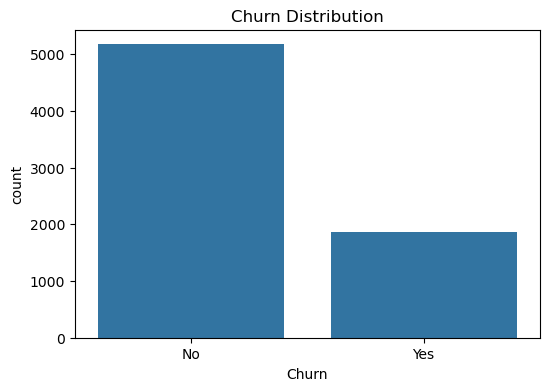

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(data=Data, x='Churn')
plt.title('Churn Distribution')
plt.show()

The dataset is slightly imbalanced, with non-churn customers representing the majority. This suggests that evaluation metrics beyond accuracy, such as F1-score and ROC-AUC, should be considered during model development.

#### 3.2 Contract Type vs Churn

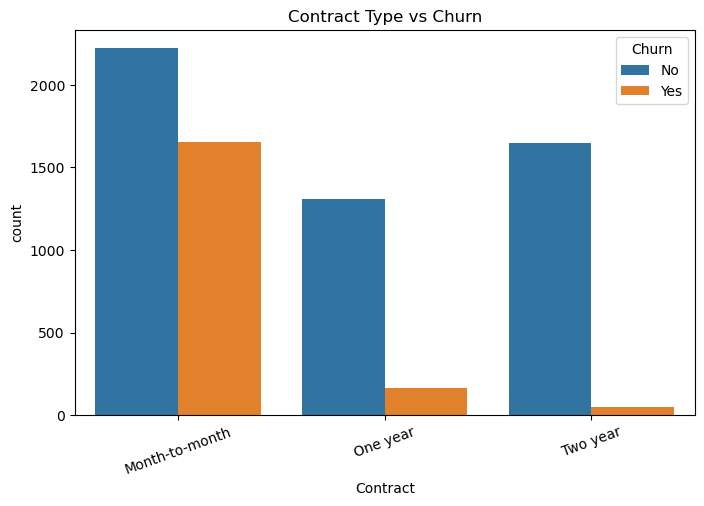

In [6]:
plt.figure(figsize=(8,5))
sns.countplot(data=Data, x='Contract', hue='Churn')
plt.title('Contract Type vs Churn')
plt.xticks(rotation=20)
plt.show()

Customers with month-to-month contracts exhibit the highest churn rate, while customers on one-year and two-year contracts are significantly more likely to remain loyal.

#### 3.3 Monthly Charges Distribution

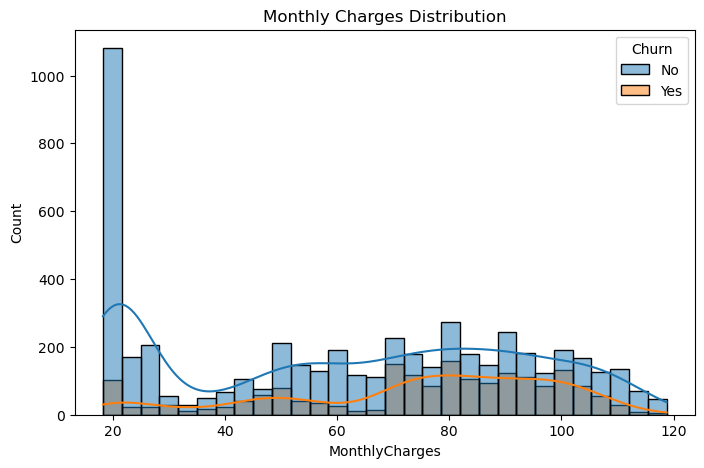

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(data=Data,
             x='MonthlyCharges',
             hue='Churn',
             kde=True,
             bins=30)
plt.title('Monthly Charges Distribution')
plt.show()

Customers with higher monthly charges appear more likely to churn, indicating that pricing may influence customer retention.

#### 3.4 Tenure vs Churn

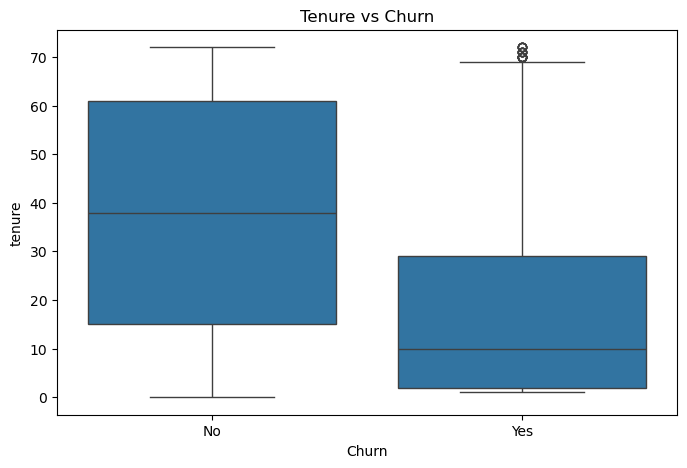

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(data=Data,
            x='Churn',
            y='tenure')
plt.title('Tenure vs Churn')
plt.show()

Customers who churn generally have much shorter tenure compared to retained customers, suggesting that churn is more common during the early stages of the customer lifecycle.

#### 3.5 Total Charges Distribution

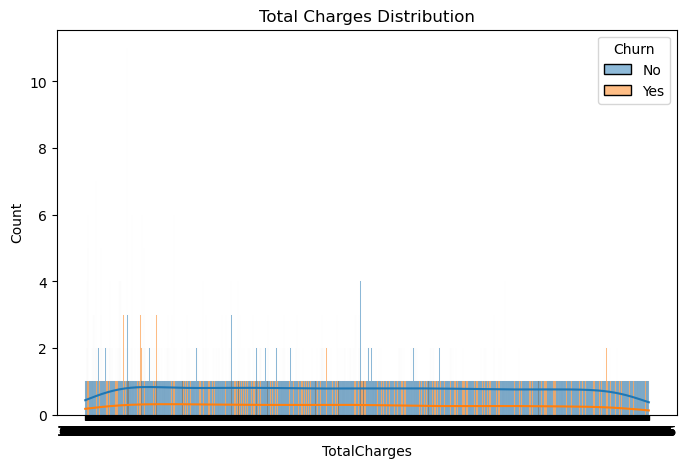

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(data=Data,
             x='TotalCharges',
             hue='Churn',
             kde=True)
plt.title('Total Charges Distribution')
plt.show()

Customers with lower accumulated total charges tend to churn more frequently, reflecting the relationship between short tenure and customer attrition.

#### 3.6 Payment Method vs Churn

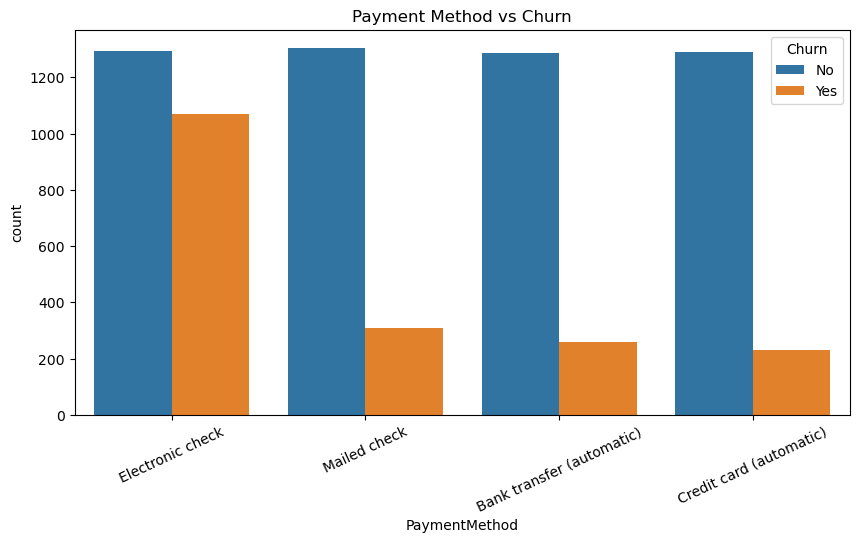

In [10]:
plt.figure(figsize=(10,5))
sns.countplot(data=Data,
              x='PaymentMethod',
              hue='Churn')
plt.xticks(rotation=25)
plt.title('Payment Method vs Churn')
plt.show()

Electronic check users show the highest churn rate, while customers using automatic payment methods demonstrate stronger retention.

#### 3.7 Internet Service vs Churn

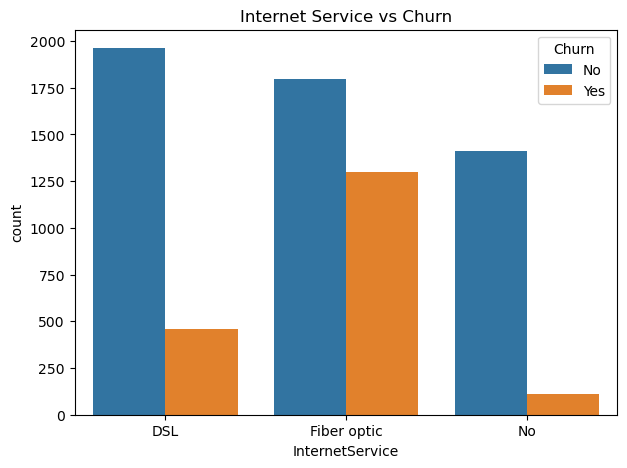

In [11]:
plt.figure(figsize=(7,5))
sns.countplot(data=Data,
              x='InternetService',
              hue='Churn')
plt.title('Internet Service vs Churn')
plt.show()

Fiber optic customers appear to churn more frequently than DSL users, indicating possible differences in customer expectations or pricing.

#### 3.8 Senior Citizen vs Churn

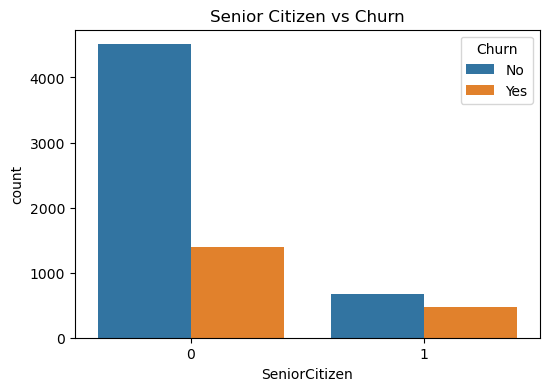

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(data=Data,
              x='SeniorCitizen',
              hue='Churn')
plt.title('Senior Citizen vs Churn')
plt.show()

Senior citizens demonstrate a relatively higher churn rate compared to younger customers, suggesting that age may influence customer retention.

#### 3.9 Correlation Heatmap

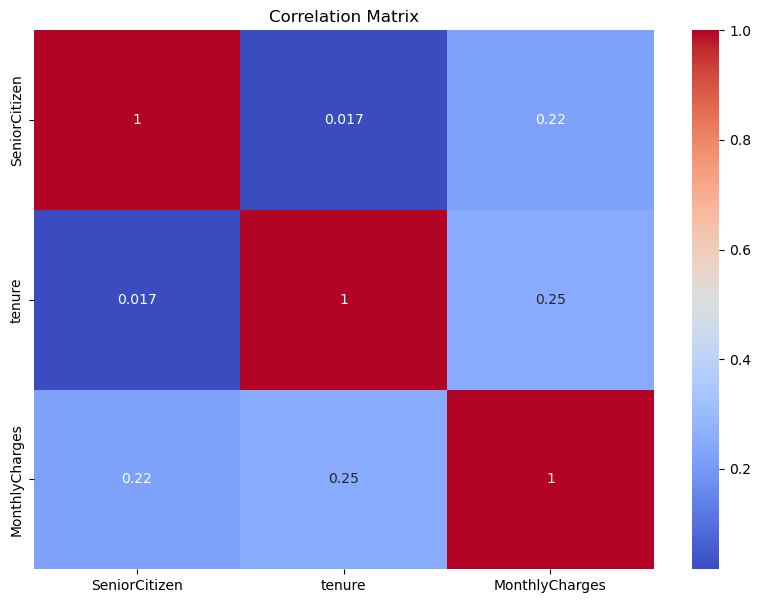

In [13]:
plt.figure(figsize=(10,7))
sns.heatmap(Data.select_dtypes(include='number').corr(),
            annot=True,
            cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Tenure and Total Charges exhibit a strong positive correlation, while Monthly Charges show a moderate relationship with customer churn.

#### 3.10 Pairplot of Numerical Features

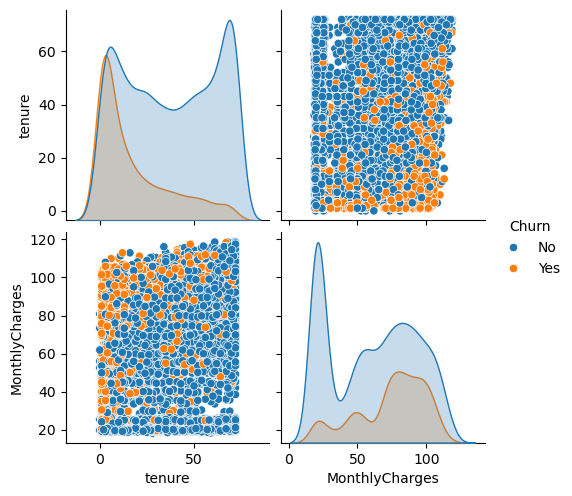

In [14]:
sns.pairplot(
    Data[['tenure',
        'MonthlyCharges',
        'TotalCharges',
        'Churn']],
    hue='Churn'
)
plt.show()

The pairwise relationships indicate that customers with shorter tenure and higher monthly charges tend to cluster within the churn class, suggesting these variables are valuable predictors for machine learning models.

#### 3.11 Gender vs Churn

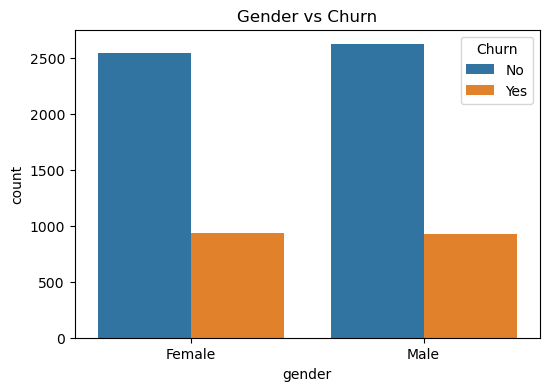

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(data=Data, x='gender', hue='Churn')
plt.title('Gender vs Churn')
plt.show()

The churn rate appears relatively similar between male and female customers, suggesting that gender is not a strong predictor of customer attrition.

#### 3.12 Dependents vs Churn

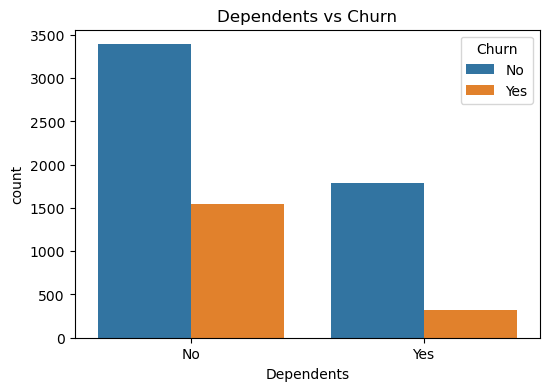

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(data=Data, x='Dependents', hue='Churn')
plt.title('Dependents vs Churn')
plt.show()

Customers without dependents tend to churn more frequently than those with dependents, indicating that family-related commitments may contribute to customer retention.

#### 3.13 Paperless Billing vs Churn

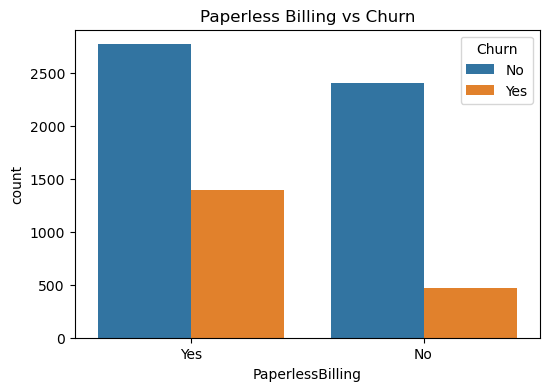

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(data=Data, x='PaperlessBilling', hue='Churn')
plt.title('Paperless Billing vs Churn')
plt.show()

Customers enrolled in paperless billing exhibit a higher churn rate, possibly due to its association with month-to-month contracts.

#### 3.14 Online Security vs Churn

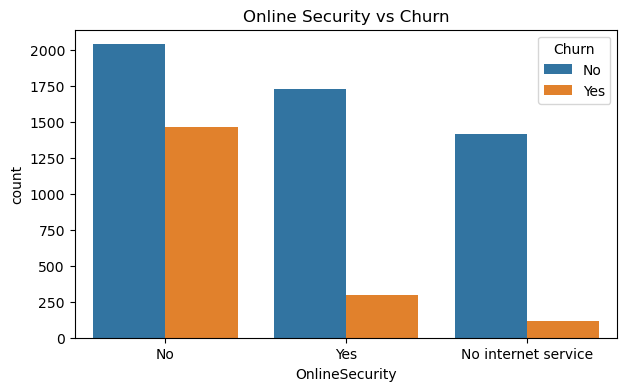

In [18]:
plt.figure(figsize=(7,4))
sns.countplot(data=Data, x='OnlineSecurity', hue='Churn')
plt.title('Online Security vs Churn')
plt.show()

Customers without the Online Security service are considerably more likely to churn, suggesting that value-added services may improve customer loyalty.

#### 3.15 Tech Support vs Churn

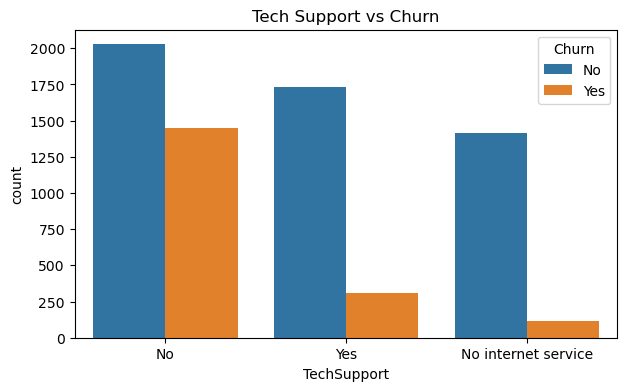

In [19]:
plt.figure(figsize=(7,4))
sns.countplot(data=Data, x='TechSupport', hue='Churn')
plt.title('Tech Support vs Churn')
plt.show()

Customers who do not subscribe to Tech Support have noticeably higher churn rates, indicating that support services may positively impact customer satisfaction and retention.